In [8]:
import numpy as np
import torch

def generate_er_graph(n, p):
	graph = np.zeros([n, n])
	idx = np.triu_indices(n, k=1)
	graph.ravel()[np.ravel_multi_index(idx, (n, n))] = np.array(np.random.rand(len(idx[0])) < p, dtype=int)
	return graph + graph.T, np.array([])

def generate_rgg_graph(n, d):
	nodes = np.random.rand(n, 2)
	graph = np.zeros([n, n])
	idx = np.triu_indices(n, k=1)
	graph.ravel()[np.ravel_multi_index(idx, (n, n))] = np.array([d > ((nodes[i[0]][0] - nodes[i[1]][0])**2 + (nodes[i[0]][1] - nodes[i[1]][1])**2)**0.5 for i in np.array(idx).T], dtype=int)
	return graph + graph.T, nodes

def generate_scalefree_graph(n, m=2):
	edges = np.zeros([n,n])
	edges[1,0] = 1
	for i in range(m, n):
		prob = (np.sum(edges, axis=1) + np.sum(edges, axis=0)) / (2 * np.sum(edges))
		edges[i,np.random.choice(n, p=prob, size=m)] = 1
	return edges + edges.T, np.array([])

def generate_graph(params):
	if params['graph'] == 'ER':
		return generate_er_graph(params['n'], params['p'])
	elif params['graph'] == 'RGG':
		return generate_rgg_graph(params['n'], params['d'])
	elif params['graph'] == 'scalefree':
		return generate_scalefree_graph(params['n'], params['sf_m'])

def migration_network(params, graph):
	if params['geneflow'] == 'Fixed out':
		n = graph.shape[0]
		M = graph * (params['m'] / np.maximum(1, np.sum(graph, axis=0))) ## If gene flow out is fixed, columns should sum to 1 before normalization
		M[range(n), range(n)] = 1 - params['m'] ## Diagonal is simply 1 - m because the gene flow out is fixed
		M = M / np.sum(M, axis=1)[:,None] ## Normalize rows
	elif params['geneflow'] == 'Fixed in':
		n = graph.shape[0]
		M = graph * (params['m'] / np.maximum(1, np.sum(graph, axis=1)))[:,None] ## If gene flow in is fixed, row should sum to 1 before normalization
		M[range(n), range(n)] = 1 - np.sum(M, axis=1)
	else:
		n = graph.shape[0]
		M = graph * params['m'] ## All gene flow is equal to m
		M[range(n), range(n)] = 1 - np.sum(M, axis=1) ## Diagonal is 1 - m * connections
	return M

def edge_lines_from_nodes(M, nodes):
	if len(nodes) == 0:
		return []
	indices = np.triu_indices(M.shape[0], k=1)
	edges = np.array(indices).T[M[indices] > 0.0001]
	lines = nodes[edges]
	return lines

def initial(params):
	if params['rand_seed'] != '':
		np.random.seed(int(params['rand_seed']))
	else:
		np.random.seed()
	edges, nodes = generate_graph(params)
	M = migration_network(params, edges)
	q = np.zeros(M.shape[0])
	if params['graph'] == 'scalefree':
		params['target'] = np.random.choice(M.shape[0]) if params['target'] == 0 else params['target']
	q[params['target']] = params['q0']
	nodes_q = np.insert(nodes, 2, q, axis=1) if len(nodes) > 0 else np.ndarray([0,3])
	return {'q': q, 'q_target': params['q0'], 'q_non_target': 0, 'spillover': 0, 'M': M, 'topology': nodes, 'nodes_edges': [nodes_q, edge_lines_from_nodes(M, nodes)]}

def step(params, _step, t):
	if t == 0:
		return initial(params)
	M = np.array(_step['M']) ## Migration network, generated in first step by "initial"
	s = params['s']
	c = params['c']
	h = params['h']
	s_c = (1 - h * s) * c ## Gametic
	s_n = 0.5 * (1 - h * s) * (1 - c)
	q_tilde = np.dot(_step['q'], M)
	w_bar = q_tilde**2 * (1 - s) + 2 * q_tilde * (1 - q_tilde) * (s_c + 2 * s_n) + (1 - q_tilde)**2
	q_tag = (q_tilde**2 * (1 - s) + 2 * q_tilde * (1 - q_tilde) * (s_c + s_n)) / w_bar
	nodes_q = np.insert(_step['topology'], 2, q_tag, axis=1) if len(_step['topology']) > 0 else np.ndarray([0,3])
	return {'q': q_tag, 'q_target': q_tag[params['target']], 'q_non_target': (np.sum(q_tag) - q_tag[params['target']]) / (M.shape[0] - 1), 'spillover': len(q_tag[q_tag > 0.5]) - 1, 'M': M, 'topology': _step['topology'], 'nodes_edges': [nodes_q, edge_lines_from_nodes(M, np.array(_step['topology']))]}

/home/jupyter-nadavbennun/.local/lib/python3.9/site-packages/networkx/drawing/nx_pylab.py:437: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


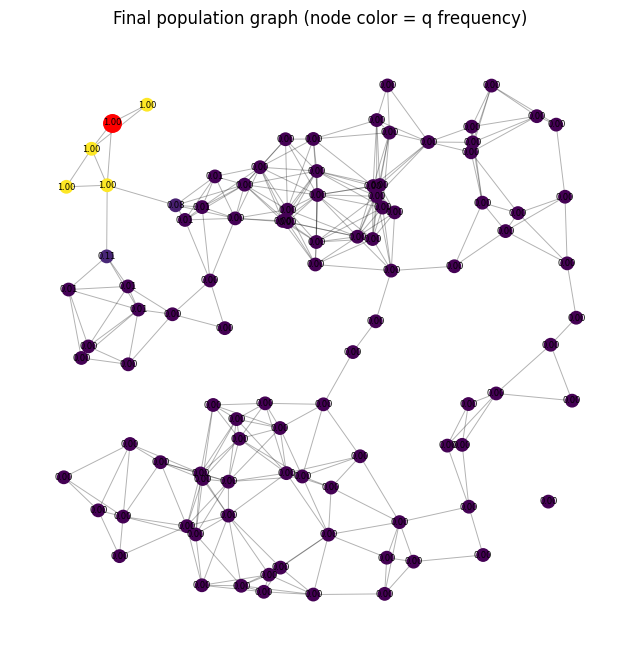

In [9]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# use params from this notebook (example)
params = {
    'graph': 'ER',
    'n': 100,
    'p': 0.15,
    'geneflow': 'Scaling',
    'm': 0.01,
    's': 0.55,
    'c': 1,
    'h': 1,
    'q0': 1,
    'target': 0,
    'rand_seed': 1111,
    'graph': 'RGG',
    'd': 0.15,

}

# run the simulation for a few timesteps
x = step(params, None, 0)
for t in range(1, 100):
    x = step(params, x, t)

# migration matrix and node data
M = np.array(x['M'])
nodes = np.array(x['topology'])       # shape (n,2) if positions exist, else empty array
q = np.array(x['q'])                  # allele frequencies per node
nodes_edges = x.get('nodes_edges', [None, None])

# build an undirected adjacency from M (ignore self-loops)
A = (M.copy())
np.fill_diagonal(A, 0)
adj = (A > 1e-8).astype(int)

G = nx.from_numpy_array(adj)

# node positions: use provided topology if present, otherwise spring layout
if nodes.size != 0 and nodes.shape[1] >= 2:
    pos = {i: (nodes[i,0], nodes[i,1]) for i in range(nodes.shape[0])}
else:
    pos = nx.spring_layout(G, seed=params.get('rand_seed', None))

# node colors by q (normalize between 0 and 1)
if q is None or len(q) == 0:
    node_colors = 'gray'
else:
    qnorm = (q - np.min(q)) / (np.ptp(q) + 1e-12)
    node_colors = plt.cm.viridis(qnorm)

# draw graph
plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.7)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=80, cmap='viridis')
# optional: draw target as larger marker
target = params.get('target', None)
if target is not None and target < len(q):
    nx.draw_networkx_nodes(G, pos, nodelist=[target], node_color='red', node_size=160)

# labels: show q value rounded
labels = {i: f"{q[i]:.2f}" for i in range(len(q))}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=6)

plt.title("Final population graph (node color = q frequency)")
plt.axis('off')
plt.show()


In [10]:
def simulate(theta, params=None, seed=None):
    """
    Simulator that uses only the functions defined in the first cell:
      - generate_graph(params)
      - migration_network(params, graph)
      - initial(params)
      - step(params, state, t)
    Adds stochastic observation noise and partial observation to make likelihood intractable.

    Returns:
      obs: dict with 'y' (observed counts or proportions) and 'meta' (obs nodes/times etc.)
      full: dict with latent graph, full q-trajectory (deterministic), and params used
    """
    import numpy as np
    import torch

    if params is None:
        params = {}
    rng = np.random.RandomState(seed)

    # build latent graph using the existing generate_graph
    # generate_graph expects params keys like 'graph','n','p','d','sf_m'
    edges, nodes = generate_graph(params)
    M = migration_network(params, edges)

    # run deterministic dynamics (use initial() and step())
    state = initial(params)
    T = int(params.get("T", 20))
    qs = [np.array(state['q']).copy()]
    for t in range(1, T + 1):
        state = step(params, state, t)
        qs.append(np.array(state['q']).copy())
    qs = np.stack(qs, axis=0)  # shape (T+1, n_nodes)

    # make stochastic counts from final frequencies (introduce stochasticity externally)
    final_q = qs[-1]
    n_nodes = final_q.shape[0]
    samp_size = int(params.get("samp_size", 30))
    obs_frac = float(params.get("obs_frac", 0.25))
    k = max(1, int(obs_frac * n_nodes))
    obs_nodes = sorted(rng.choice(n_nodes, k, replace=False).tolist())

    # observed counts at selected times (default final only)
    obs_times = params.get("obs_times", [T])
    observations = []
    for t in obs_times:
        freqs = qs[t]
        counts = np.array([rng.binomial(samp_size, np.clip(freqs[i], 0.0, 1.0)) for i in obs_nodes])
        if params.get("obs_mode", "counts") == "proportions":
            observations.append(counts / samp_size)
        else:
            observations.append(counts)
    obs_array = np.stack(observations, axis=0)  # (n_times, n_obs_nodes)

    obs = {"y": obs_array, "meta": {"obs_nodes": obs_nodes, "obs_times": obs_times, "samp_size": samp_size}}
    full = {"latent_edges": edges, "latent_nodes": nodes, "M": M, "qs": qs, "params": params, "theta": theta}
    return obs, full

obs keys: dict_keys(['y', 'meta'])
observed array shape (times, nodes): (1, 15)
obs meta: {'obs_nodes': [4, 6, 8, 13, 18, 20, 22, 29, 31, 33, 39, 45, 46, 51, 54], 'obs_times': [30], 'samp_size': 30}


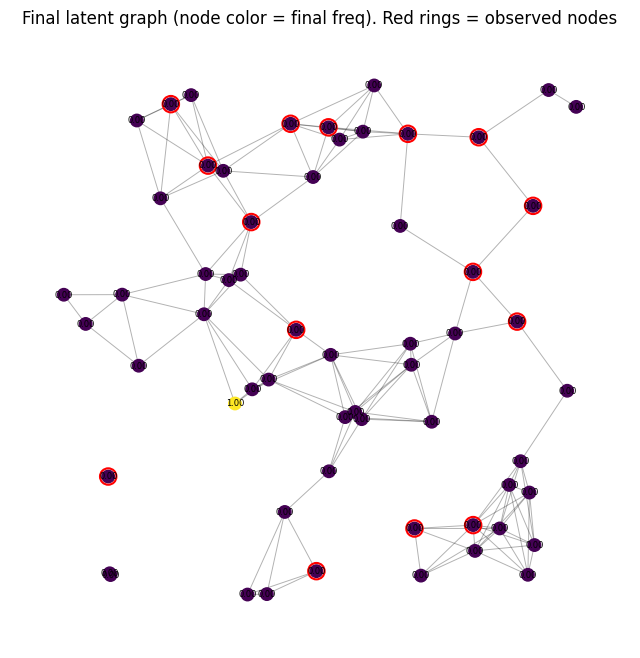

Saved intractable_obs.pt and intractable_full.pt


In [11]:
# small theta (simulator uses functions from first cell; theta is returned in 'full')
theta = {}

# simulation parameters
params = {
    "graph": "RGG",        # used by generate_graph in the first cell
    "n": 60,
    "d": 0.18,
    "geneflow": "Scaling",
    "m": 0.01,
    "s": 0.2,
    "c": 1.0,
    "h": 1.0,
    "q0": 1,
    "target": 0,
    "rand_seed": 42,
    "T": 30,
    "obs_times": [30],     # observe final time
    "obs_frac": 0.25,      # fraction of nodes observed
    "samp_size": 30,
    "obs_mode": "counts",  # or "proportions"
}

# call simulate defined in the notebook's cells
obs, full = simulate(theta, params=params, seed=1234)

# inspect observation
print("obs keys:", obs.keys())
print("observed array shape (times, nodes):", obs["y"].shape)
print("obs meta:", obs["meta"])

# build graph from migration / adjacency (ignore self-loops)
M = np.array(full["M"])
A = M.copy()
np.fill_diagonal(A, 0)
adj = (A > 1e-8).astype(int)
G = nx.from_numpy_array(adj)

# node positions: use latent topology if available, otherwise spring layout
nodes = full.get("latent_nodes", np.array([]))
if isinstance(nodes, np.ndarray) and nodes.size != 0 and nodes.shape[1] >= 2:
    pos = {i: (nodes[i,0], nodes[i,1]) for i in range(nodes.shape[0])}
else:
    pos = nx.spring_layout(G, seed=params.get("rand_seed"))

# color nodes by final frequency from full['qs']
qs = np.array(full["qs"])  # shape (T+1, n)
final_freqs = qs[-1]
qnorm = (final_freqs - np.min(final_freqs)) / (np.ptp(final_freqs) + 1e-12)
node_colors = plt.cm.viridis(qnorm)

plt.figure(figsize=(8,8))
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.7)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=80, cmap="viridis")
# highlight observed nodes
obs_nodes = obs["meta"]["obs_nodes"]
nx.draw_networkx_nodes(G, pos, nodelist=obs_nodes, node_size=140, node_color="none", edgecolors="red", linewidths=1.5)
labels = {i: f"{final_freqs[i]:.2f}" for i in range(len(final_freqs))}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=6)
plt.title("Final latent graph (node color = final freq). Red rings = observed nodes")
plt.axis("off")
plt.show()

# save outputs for downstream inference
torch.save(obs, "intractable_obs.pt")
torch.save(full, "intractable_full.pt")
print("Saved intractable_obs.pt and intractable_full.pt")

In [14]:
full

{'latent_edges': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 'latent_nodes': array([[0.33409176, 0.36257654],
        [0.65502905, 0.69778897],
        [0.60450714, 0.9629664 ],
        [0.32220986, 0.59551135],
        [0.45294991, 0.50164571],
        [0.27710724, 0.60696264],
        [0.80763316, 0.86521571],
        [0.90307704, 0.03920652],
        [0.49224574, 0.04605404],
        [0.36758272, 0.3893354 ],
        [0.56763025, 0.34660937],
        [0.39601763, 0.00273423],
        [0.09069539, 0.04205278],
        [0.66999925, 0.87164703],
        [0.00155272, 0.56790177],
        [0.14709297, 0.43389201],
        [0.84838327, 0.12671322],
        [0.58018843, 0.33303044],
        [0.79643238, 0.61104302],
        [0.58264777, 0.87576472],
        [0.20950576, 0.92766833],
     